# 07 — Customer Satisfaction Analytics

## Olist E-Commerce Business Analytics

### Objective

This notebook investigates the historical factors associated with customer review outcomes.

The analysis covers:

- Review availability and score distribution
- Low- and high-satisfaction groups
- Delivery status and delay severity
- Product-category differences
- Order and freight values
- Payment behaviour
- Geographic patterns
- Seller involvement
- Customer-experience investigation priorities

Review scores represent observed customer feedback. The analysis identifies associations but does not prove that any individual factor caused a particular score.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

plt.style.use("seaborn-v0_8-whitegrid")

COLORS = {
    "primary": "#173F5F",
    "secondary": "#20639B",
    "accent": "#F6C85F",
    "positive": "#3CAEA3",
    "negative": "#ED553B",
    "neutral": "#8A8A8A"
}

PROCESSED_DATA_DIR = Path("../data/processed").resolve()
IMAGE_OUTPUT_DIR = Path(
    "../images/notebook_outputs"
).resolve()

IMAGE_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Processed data:", PROCESSED_DATA_DIR.exists())
print("Image output:", IMAGE_OUTPUT_DIR.exists())

Processed data: True
Image output: True


In [2]:
order_analytics = pd.read_csv(
    PROCESSED_DATA_DIR / "order_analytics.csv",
    dtype={
        "customer_zip_code_prefix": "string"
    },
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "latest_review_date",
        "latest_review_answer_timestamp"
    ]
)

reviewed_orders = order_analytics.loc[
    order_analytics["latest_review_score"].notna()
].copy()

reviewed_delivered_orders = reviewed_orders.loc[
    reviewed_orders["order_status"] == "delivered"
].copy()

print("All orders:", f"{len(order_analytics):,}")
print("Orders with reviews:", f"{len(reviewed_orders):,}")
print(
    "Delivered orders with reviews:",
    f"{len(reviewed_delivered_orders):,}"
)

print(
    "Delivered-review coverage:",
    f"{len(reviewed_delivered_orders) / (order_analytics['order_status'] == 'delivered').sum():.2%}"
)

All orders: 99,441
Orders with reviews: 98,673
Delivered orders with reviews: 95,832
Delivered-review coverage: 99.33%


***Population definition:*** General review coverage uses all reviewed orders. Driver comparisons primarily use delivered orders with a recorded latest review because incomplete orders follow different operational paths.

***Metric definition:*** Scores of 1–2 represent low satisfaction, score 3 represents neutral feedback, and scores of 4–5 represent high satisfaction.

## 1. Satisfaction Baseline

Reviewed delivered orders are grouped into low, neutral, and high satisfaction. The groups are compared across payment value, delivery performance, and written-feedback behaviour.

In [3]:
reviewed_delivered_orders[
    "satisfaction_group"
] = pd.cut(
    reviewed_delivered_orders[
        "latest_review_score"
    ],
    bins=[0, 2, 3, 5],
    labels=[
        "Low satisfaction (1–2)",
        "Neutral (3)",
        "High satisfaction (4–5)"
    ]
)

reviewed_delivered_orders[
    "valid_late_delivery_flag"
] = np.where(
    reviewed_delivered_orders[
        "is_late_delivery"
    ].notna(),
    reviewed_delivered_orders[
        "is_late_delivery"
    ].eq(True).astype(int),
    np.nan
)

In [4]:
satisfaction_baseline = (
    reviewed_delivered_orders
    .groupby(
        "satisfaction_group",
        observed=True,
        as_index=False
    )
    .agg(
        reviewed_orders=("order_id", "nunique"),
        average_review_score=("latest_review_score", "mean"),
        average_payment_value=("total_payment_value", "mean"),
        average_product_value=("product_value", "mean"),
        average_freight_value=("freight_value", "mean"),
        average_delivery_days=("delivery_days", "mean"),
        late_delivery_rate=(
            "valid_late_delivery_flag",
            "mean"
        ),
        written_feedback_rate=(
            "has_written_feedback",
            "mean"
        )
    )
)

satisfaction_baseline["review_share"] = (
    satisfaction_baseline["reviewed_orders"]
    / satisfaction_baseline["reviewed_orders"].sum()
)

satisfaction_baseline.style.format({
    "reviewed_orders": "{:,.0f}",
    "average_review_score": "{:.2f}",
    "average_payment_value": "R$ {:,.2f}",
    "average_product_value": "R$ {:,.2f}",
    "average_freight_value": "R$ {:,.2f}",
    "average_delivery_days": "{:.2f}",
    "late_delivery_rate": "{:.2%}",
    "written_feedback_rate": "{:.2%}",
    "review_share": "{:.2%}"
})

,satisfaction_group,reviewed_orders,average_review_score,average_payment_value,average_product_value,average_freight_value,average_delivery_days,late_delivery_rate,written_feedback_rate,review_share
0,Low satisfaction (1–2),"12,273",1.24,R$ 187.63,R$ 159.88,R$ 27.71,20.23,32.50%,76.01%,12.81%
1,Neutral (3),"7,916",3.00,R$ 151.11,R$ 127.49,R$ 23.56,14.27,8.78%,44.52%,8.26%
2,High satisfaction (4–5),"75,643",4.75,R$ 155.93,R$ 134.03,R$ 21.88,11.09,2.26%,36.76%,78.93%


In [5]:
print(
    "Reviewed delivered orders represented:",
    f"{satisfaction_baseline['reviewed_orders'].sum():,}"
)

print(
    "Expected reviewed delivered orders:",
    f"{len(reviewed_delivered_orders):,}"
)

Reviewed delivered orders represented: 95,832
Expected reviewed delivered orders: 95,832


***Observation:*** Low-satisfaction orders represented 12.81% of reviewed delivered orders. They took an average of 20.23 days to arrive, compared with 11.09 days for high-satisfaction orders, and their late-delivery rate was 32.50% versus only 2.26%.

***Customer behaviour:*** Written feedback appeared in 76.01% of low-satisfaction orders, compared with 36.76% of high-satisfaction orders. Dissatisfied customers were therefore much more likely to explain their experience in writing.

***Order-value pattern:*** Low-satisfaction orders had higher average payment, product, and freight values than the other groups. This may reflect differences in product mix, item quantity, shipping complexity, or customer expectations; it does not prove that higher spending causes dissatisfaction.

***Coverage validation:*** The three groups represent all 95,832 reviewed delivered orders.

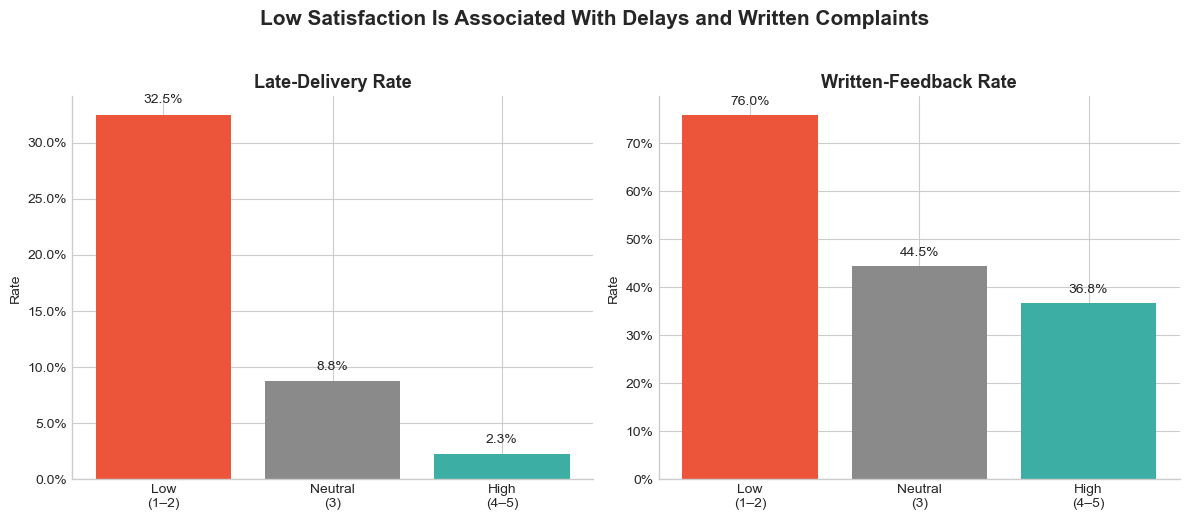

In [6]:
plot_data = satisfaction_baseline.copy()

group_labels = [
    "Low\n(1–2)",
    "Neutral\n(3)",
    "High\n(4–5)"
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

bars_1 = axes[0].bar(
    group_labels,
    plot_data["late_delivery_rate"],
    color=[
        COLORS["negative"],
        COLORS["neutral"],
        COLORS["positive"]
    ]
)

axes[0].set_title(
    "Late-Delivery Rate",
    fontsize=13,
    fontweight="bold"
)
axes[0].set_ylabel("Rate")
axes[0].yaxis.set_major_formatter(
    mtick.PercentFormatter(1.0)
)

for bar, value in zip(
    bars_1,
    plot_data["late_delivery_rate"]
):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{value:.1%}",
        ha="center"
    )

bars_2 = axes[1].bar(
    group_labels,
    plot_data["written_feedback_rate"],
    color=[
        COLORS["negative"],
        COLORS["neutral"],
        COLORS["positive"]
    ]
)

axes[1].set_title(
    "Written-Feedback Rate",
    fontsize=13,
    fontweight="bold"
)
axes[1].set_ylabel("Rate")
axes[1].yaxis.set_major_formatter(
    mtick.PercentFormatter(1.0)
)

for bar, value in zip(
    bars_2,
    plot_data["written_feedback_rate"]
):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{value:.1%}",
        ha="center"
    )

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "Low Satisfaction Is Associated With Delays and Written Complaints",
    fontsize=15,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()

plt.savefig(
    IMAGE_OUTPUT_DIR
    / "satisfaction_group_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

***Chart interpretation:*** Low-satisfaction orders are considerably more likely to arrive late and include written feedback. Written comments from this group should be prioritised in the later NLP review analysis to identify recurring complaint themes.

## 2. Product-Category Satisfaction

Customer satisfaction is compared across product categories using reviewed delivered orders. Rankings require at least 500 reviewed orders to reduce instability from small category samples.

In [7]:
order_items = pd.read_csv(
    PROCESSED_DATA_DIR / "order_items_clean.csv"
)

products = pd.read_csv(
    PROCESSED_DATA_DIR / "products_clean.csv"
)

category_translation = pd.read_csv(
    PROCESSED_DATA_DIR
    / "category_translation_clean.csv"
)

item_categories = (
    order_items
    .merge(
        products[
            [
                "product_id",
                "product_category_name"
            ]
        ],
        on="product_id",
        how="left",
        validate="many_to_one"
    )
    .merge(
        category_translation,
        on="product_category_name",
        how="left",
        validate="many_to_one"
    )
)

In [8]:
category_review_bridge = (
    item_categories
    .groupby(
        [
            "order_id",
            "product_category_name_english"
        ],
        as_index=False
    )
    .agg(
        category_item_count=("order_item_id", "count"),
        category_product_value=("price", "sum"),
        category_freight_value=("freight_value", "sum")
    )
    .merge(
        reviewed_delivered_orders[
            [
                "order_id",
                "latest_review_score",
                "satisfaction_group",
                "delivery_days",
                "valid_late_delivery_flag"
            ]
        ],
        on="order_id",
        how="inner",
        validate="many_to_one"
    )
)

category_review_bridge["low_satisfaction_flag"] = (
    category_review_bridge[
        "latest_review_score"
    ] <= 2
)

In [9]:
category_review_validation = pd.DataFrame([
    {
        "validation_check": "Duplicate order-category combinations",
        "result": category_review_bridge.duplicated(
            subset=[
                "order_id",
                "product_category_name_english"
            ]
        ).sum(),
        "expected": 0
    },
    {
        "validation_check": "Missing English categories",
        "result": category_review_bridge[
            "product_category_name_english"
        ].isna().sum(),
        "expected": 0
    },
    {
        "validation_check": "Invalid review scores",
        "result": (
            ~category_review_bridge[
                "latest_review_score"
            ].between(1, 5)
        ).sum(),
        "expected": 0
    }
])

category_review_validation["status"] = np.where(
    category_review_validation["result"]
    == category_review_validation["expected"],
    "Passed",
    "Failed"
)

category_review_validation

,validation_check,result,expected,status
0,Duplicate order-category combinations,0,0,Passed
1,Missing English categories,0,0,Passed
2,Invalid review scores,0,0,Passed


In [10]:
category_satisfaction = (
    category_review_bridge
    .groupby(
        "product_category_name_english",
        as_index=False
    )
    .agg(
        reviewed_orders=("order_id", "nunique"),
        average_review_score=("latest_review_score", "mean"),
        low_satisfaction_rate=("low_satisfaction_flag", "mean"),
        average_delivery_days=("delivery_days", "mean"),
        late_delivery_rate=(
            "valid_late_delivery_flag",
            "mean"
        ),
        product_value=("category_product_value", "sum"),
        freight_value=("category_freight_value", "sum")
    )
)

reliable_category_satisfaction = (
    category_satisfaction.loc[
        category_satisfaction[
            "reviewed_orders"
        ] >= 500
    ]
    .sort_values(
        "low_satisfaction_rate",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Categories meeting the minimum:",
    len(reliable_category_satisfaction)
)

reliable_category_satisfaction.head(10).style.format({
    "reviewed_orders": "{:,.0f}",
    "average_review_score": "{:.2f}",
    "low_satisfaction_rate": "{:.2%}",
    "average_delivery_days": "{:.2f}",
    "late_delivery_rate": "{:.2%}",
    "product_value": "R$ {:,.2f}",
    "freight_value": "R$ {:,.2f}"
})

Categories meeting the minimum: 26


,product_category_name_english,reviewed_orders,average_review_score,low_satisfaction_rate,average_delivery_days,late_delivery_rate,product_value,freight_value
0,office_furniture,"1,244",3.64,21.95%,20.59,7.96%,"R$ 265,269.64","R$ 66,353.83"
1,unknown,"1,382",4.01,17.51%,12.72,7.25%,"R$ 169,652.36","R$ 26,758.86"
2,bed_bath_table,"9,177",4.00,16.04%,12.95,7.30%,"R$ 1,013,590.72","R$ 199,576.09"
3,furniture_decor,"6,260",4.06,15.35%,13.03,7.04%,"R$ 705,997.44","R$ 166,691.25"
4,computers_accessories,"6,499",4.08,14.56%,13.15,6.28%,"R$ 884,760.96","R$ 143,343.51"
5,baby,"2,787",4.10,14.28%,12.59,7.90%,"R$ 397,301.11","R$ 65,787.41"
6,telephony,"4,069",4.05,14.13%,12.96,7.06%,"R$ 307,797.66","R$ 68,968.95"
7,watches_gifts,"5,454",4.12,13.70%,12.76,7.26%,"R$ 1,159,219.92","R$ 97,415.94"
8,construction_tools_construction,731,4.13,13.27%,10.77,7.11%,"R$ 140,396.10","R$ 20,133.92"
9,electronics,"2,498",4.12,13.21%,12.91,7.62%,"R$ 151,050.36","R$ 45,164.43"


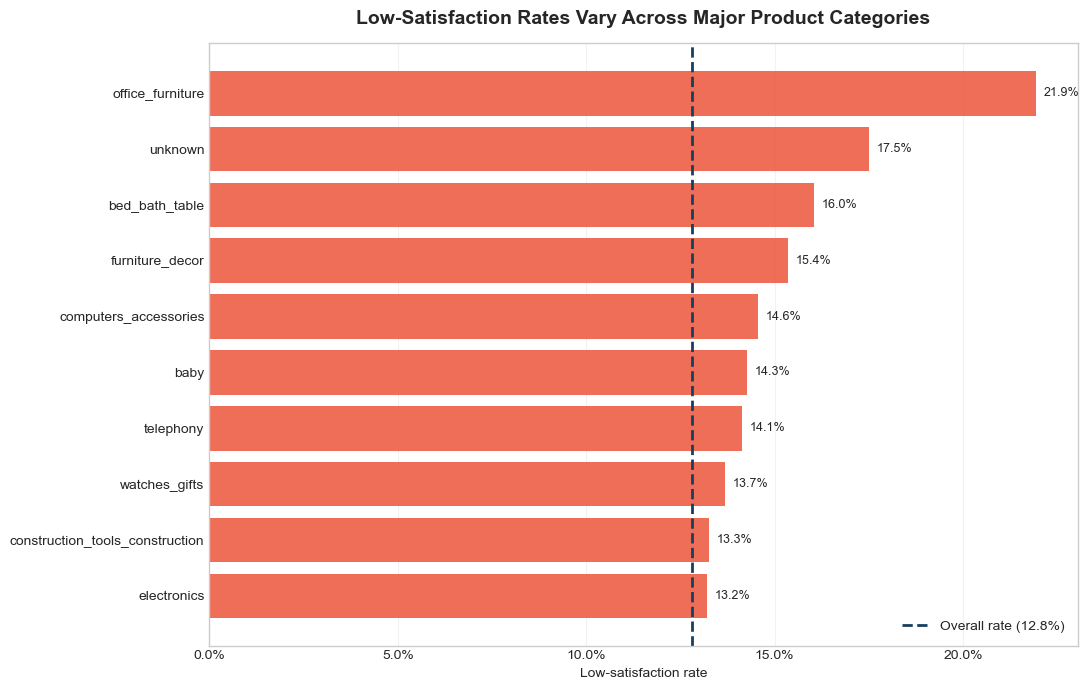

In [14]:
from matplotlib.ticker import PercentFormatter

overall_low_satisfaction_rate = (
    reviewed_delivered_orders["latest_review_score"]
    .le(2)
    .mean()
)

category_plot = (
    reliable_category_satisfaction
    .sort_values("low_satisfaction_rate", ascending=False)
    .head(10)
    .sort_values("low_satisfaction_rate")
)

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    category_plot["product_category_name_english"],
    category_plot["low_satisfaction_rate"],
    color=COLORS["negative"],
    alpha=0.85
)

ax.axvline(
    overall_low_satisfaction_rate,
    color=COLORS["primary"],
    linestyle="--",
    linewidth=2,
    label=f"Overall rate ({overall_low_satisfaction_rate:.1%})"
)

ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel("Low-satisfaction rate")
ax.set_ylabel("")
ax.set_title(
    "Low-Satisfaction Rates Vary Across Major Product Categories",
    fontsize=14,
    fontweight="bold",
    pad=14
)

for bar, value in zip(bars, category_plot["low_satisfaction_rate"]):
    ax.text(
        value + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1%}",
        va="center",
        fontsize=9
    )

ax.legend(frameon=False, loc="lower right")
ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)

plt.tight_layout()

IMAGES_DIR = Path("../images/notebook_outputs")
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

output_path = IMAGES_DIR / "category_low_satisfaction_rates.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

***Observation:*** Among categories with at least 500 reviewed delivered orders, office furniture has the highest low-satisfaction rate. These differences highlight categories for further investigation but do not establish the cause of customer dissatisfaction.

In [15]:
monthly_review_data = reviewed_delivered_orders.copy()

monthly_review_data["purchase_month_start"] = (
    monthly_review_data["order_purchase_timestamp"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

monthly_review_data["low_satisfaction_flag"] = (
    monthly_review_data["latest_review_score"] <= 2
)

monthly_review_data["high_satisfaction_flag"] = (
    monthly_review_data["latest_review_score"] >= 4
)

monthly_satisfaction = (
    monthly_review_data
    .groupby("purchase_month_start", as_index=False)
    .agg(
        reviewed_orders=("order_id", "nunique"),
        average_review_score=("latest_review_score", "mean"),
        low_satisfaction_rate=("low_satisfaction_flag", "mean"),
        high_satisfaction_rate=("high_satisfaction_flag", "mean"),
        written_feedback_rate=("has_written_feedback", "mean")
    )
)

# Keep only complete and comparable months
monthly_satisfaction_comparable = (
    monthly_satisfaction.loc[
        monthly_satisfaction["purchase_month_start"].between(
            "2017-01-01",
            "2018-08-01"
        )
    ]
    .reset_index(drop=True)
)

display(
    monthly_satisfaction_comparable.style.format({
        "purchase_month_start": "{:%Y-%m}",
        "reviewed_orders": "{:,.0f}",
        "average_review_score": "{:.2f}",
        "low_satisfaction_rate": "{:.2%}",
        "high_satisfaction_rate": "{:.2%}",
        "written_feedback_rate": "{:.2%}"
    })
)

lowest_score_month = monthly_satisfaction_comparable.loc[
    monthly_satisfaction_comparable["average_review_score"].idxmin()
]

highest_score_month = monthly_satisfaction_comparable.loc[
    monthly_satisfaction_comparable["average_review_score"].idxmax()
]

print(
    "Lowest average-score month:",
    lowest_score_month["purchase_month_start"].strftime("%Y-%m"),
    f"({lowest_score_month['average_review_score']:.2f})"
)

print(
    "Highest average-score month:",
    highest_score_month["purchase_month_start"].strftime("%Y-%m"),
    f"({highest_score_month['average_review_score']:.2f})"
)

,purchase_month_start,reviewed_orders,average_review_score,low_satisfaction_rate,high_satisfaction_rate,written_feedback_rate
0,2017-01,741,4.20,12.01%,79.76%,44.94%
1,2017-02,"1,643",4.20,11.08%,79.31%,44.07%
2,2017-03,"2,527",4.19,11.24%,79.66%,42.14%
3,2017-04,"2,290",4.14,12.88%,78.21%,41.14%
4,2017-05,"3,518",4.24,10.06%,80.90%,40.59%
5,2017-06,"3,111",4.22,10.74%,80.59%,41.76%
6,2017-07,"3,842",4.26,9.97%,81.34%,42.06%
7,2017-08,"4,165",4.31,9.39%,83.72%,40.31%
8,2017-09,"4,118",4.27,10.25%,82.25%,41.23%
9,2017-10,"4,446",4.20,11.07%,80.54%,41.32%


Lowest average-score month: 2018-03 (3.81)
Highest average-score month: 2018-07 (4.32)


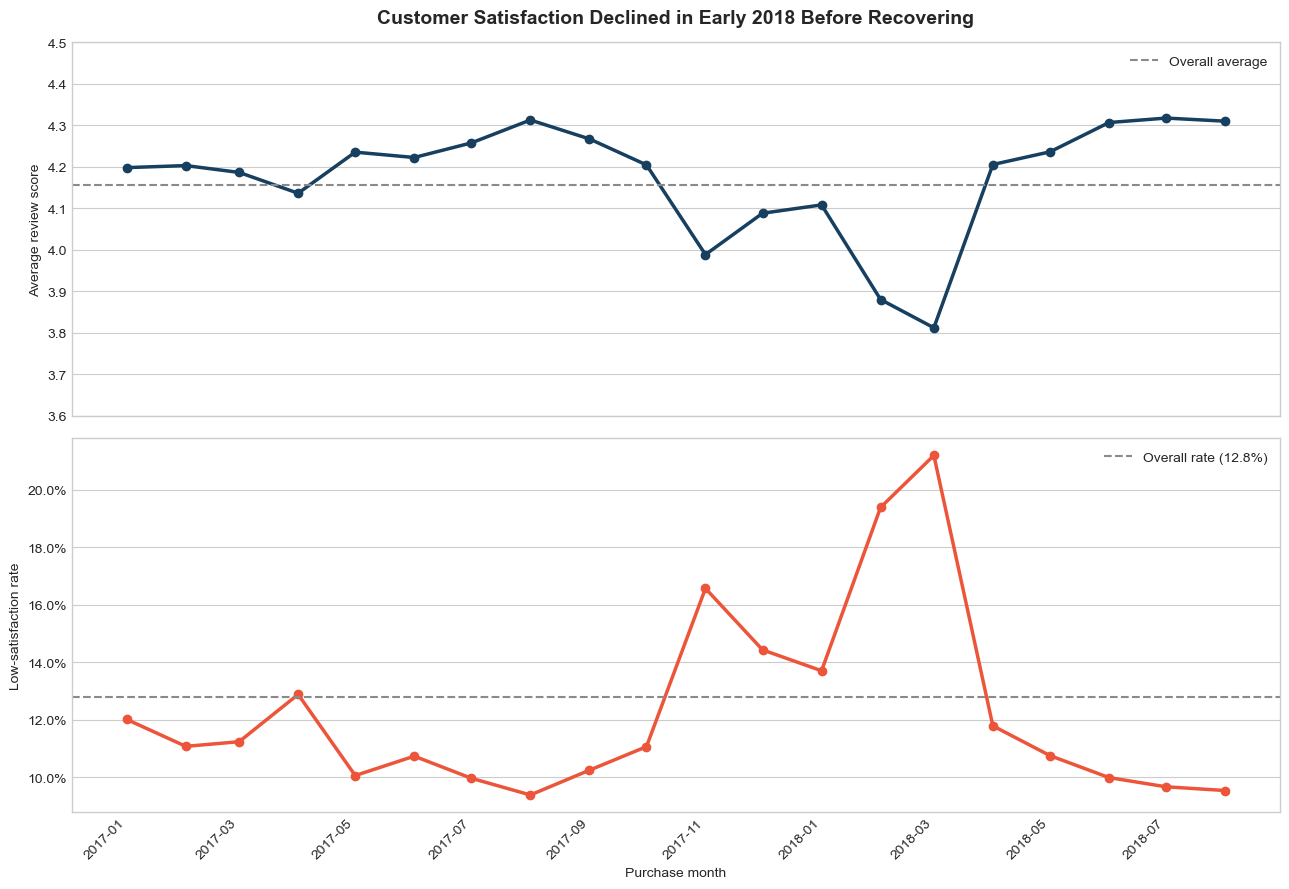

In [16]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(13, 9),
    sharex=True
)

# Average review score
axes[0].plot(
    monthly_satisfaction_comparable["purchase_month_start"],
    monthly_satisfaction_comparable["average_review_score"],
    marker="o",
    linewidth=2.5,
    color=COLORS["primary"]
)

axes[0].axhline(
    reviewed_delivered_orders["latest_review_score"].mean(),
    color=COLORS["neutral"],
    linestyle="--",
    label="Overall average"
)

axes[0].set_title(
    "Customer Satisfaction Declined in Early 2018 Before Recovering",
    fontsize=14,
    fontweight="bold",
    pad=14
)
axes[0].set_ylabel("Average review score")
axes[0].set_ylim(3.6, 4.5)
axes[0].legend(frameon=False)
axes[0].grid(axis="x", visible=False)

# Low-satisfaction rate
axes[1].plot(
    monthly_satisfaction_comparable["purchase_month_start"],
    monthly_satisfaction_comparable["low_satisfaction_rate"],
    marker="o",
    linewidth=2.5,
    color=COLORS["negative"]
)

axes[1].axhline(
    overall_low_satisfaction_rate,
    color=COLORS["neutral"],
    linestyle="--",
    label=f"Overall rate ({overall_low_satisfaction_rate:.1%})"
)

axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].set_ylabel("Low-satisfaction rate")
axes[1].set_xlabel("Purchase month")
axes[1].legend(frameon=False)
axes[1].grid(axis="x", visible=False)

fig.autofmt_xdate(rotation=45)
plt.tight_layout()

IMAGES_DIR = Path("../images/notebook_outputs")
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

plt.savefig(
    IMAGES_DIR / "monthly_satisfaction_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

***Observation:*** Average review scores declined during late 2017 and early 2018, while the low-satisfaction rate peaked at 21.19% in March 2018. Satisfaction subsequently recovered, with the average score reaching 4.32 in July 2018.

In [17]:
complexity_data = reviewed_delivered_orders.copy()

complexity_data["order_complexity"] = np.select(
    [
        complexity_data["distinct_seller_count"] > 1,
        complexity_data["item_count"] > 1
    ],
    [
        "Multiple sellers",
        "Multiple items, one seller"
    ],
    default="Single item, one seller"
)

complexity_data["low_satisfaction_flag"] = (
    complexity_data["latest_review_score"] <= 2
)

complexity_summary = (
    complexity_data
    .groupby("order_complexity", as_index=False)
    .agg(
        reviewed_orders=("order_id", "nunique"),
        average_review_score=("latest_review_score", "mean"),
        low_satisfaction_rate=("low_satisfaction_flag", "mean"),
        late_delivery_rate=("valid_late_delivery_flag", "mean"),
        average_delivery_days=("delivery_days", "mean"),
        average_payment_value=("total_payment_value", "mean")
    )
    .sort_values("low_satisfaction_rate", ascending=False)
    .reset_index(drop=True)
)

complexity_summary["order_share"] = (
    complexity_summary["reviewed_orders"]
    / complexity_summary["reviewed_orders"].sum()
)

display(
    complexity_summary.style.format({
        "reviewed_orders": "{:,.0f}",
        "average_review_score": "{:.2f}",
        "low_satisfaction_rate": "{:.2%}",
        "late_delivery_rate": "{:.2%}",
        "average_delivery_days": "{:.2f}",
        "average_payment_value": "R$ {:,.2f}",
        "order_share": "{:.2%}"
    })
)

,order_complexity,reviewed_orders,average_review_score,low_satisfaction_rate,late_delivery_rate,average_delivery_days,average_payment_value,order_share
0,Multiple sellers,"1,261",2.86,47.18%,0.97%,9.19,R$ 258.11,1.32%
1,"Multiple items, one seller","8,267",3.75,23.62%,5.81%,12.19,R$ 246.83,8.63%
2,"Single item, one seller","86,304",4.21,11.27%,6.83%,12.61,R$ 149.80,90.06%


In [18]:
complexity_data["late_delivery_for_analysis"] = (
    complexity_data["valid_late_delivery_flag"]
    .where(complexity_data["is_valid_for_delivery_analysis"])
)

complexity_summary = (
    complexity_data
    .groupby("order_complexity", as_index=False)
    .agg(
        reviewed_orders=("order_id", "nunique"),
        valid_delivery_orders=(
            "late_delivery_for_analysis",
            "count"
        ),
        average_review_score=("latest_review_score", "mean"),
        low_satisfaction_rate=("low_satisfaction_flag", "mean"),
        late_delivery_rate=("late_delivery_for_analysis", "mean"),
        average_delivery_days=("delivery_days", "mean"),
        average_payment_value=("total_payment_value", "mean")
    )
    .sort_values("low_satisfaction_rate", ascending=False)
    .reset_index(drop=True)
)

complexity_summary["order_share"] = (
    complexity_summary["reviewed_orders"]
    / complexity_summary["reviewed_orders"].sum()
)

display(
    complexity_summary.style.format({
        "reviewed_orders": "{:,.0f}",
        "valid_delivery_orders": "{:,.0f}",
        "average_review_score": "{:.2f}",
        "low_satisfaction_rate": "{:.2%}",
        "late_delivery_rate": "{:.2%}",
        "average_delivery_days": "{:.2f}",
        "average_payment_value": "R$ {:,.2f}",
        "order_share": "{:.2%}"
    })
)

print(
    "Reviewed orders represented:",
    f"{complexity_summary['reviewed_orders'].sum():,.0f}"
)
print(
    "Expected reviewed delivered orders:",
    f"{len(reviewed_delivered_orders):,.0f}"
)

,order_complexity,reviewed_orders,valid_delivery_orders,average_review_score,low_satisfaction_rate,late_delivery_rate,average_delivery_days,average_payment_value,order_share
0,Multiple sellers,"1,261","1,238",2.86,47.18%,0.97%,9.19,R$ 258.11,1.32%
1,"Multiple items, one seller","8,267","8,260",3.75,23.62%,5.81%,12.19,R$ 246.83,8.63%
2,"Single item, one seller","86,304","86,138",4.21,11.27%,6.83%,12.61,R$ 149.80,90.06%


Reviewed orders represented: 95,832
Expected reviewed delivered orders: 95,832


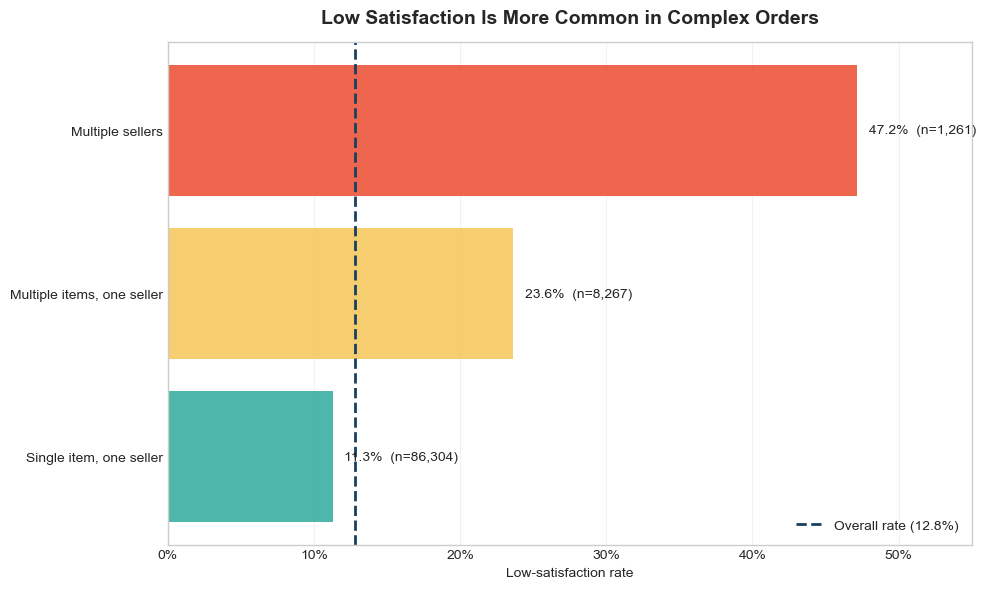

In [19]:
complexity_plot = (
    complexity_summary
    .sort_values("low_satisfaction_rate")
    .copy()
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    complexity_plot["order_complexity"],
    complexity_plot["low_satisfaction_rate"],
    color=[
        COLORS["positive"],
        COLORS["accent"],
        COLORS["negative"]
    ],
    alpha=0.9
)

ax.axvline(
    overall_low_satisfaction_rate,
    color=COLORS["primary"],
    linestyle="--",
    linewidth=2,
    label=f"Overall rate ({overall_low_satisfaction_rate:.1%})"
)

for bar, rate, count in zip(
    bars,
    complexity_plot["low_satisfaction_rate"],
    complexity_plot["reviewed_orders"]
):
    ax.text(
        rate + 0.008,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.1%}  (n={count:,.0f})",
        va="center",
        fontsize=10
    )

ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlim(0, 0.55)
ax.set_xlabel("Low-satisfaction rate")
ax.set_ylabel("")
ax.set_title(
    "Low Satisfaction Is More Common in Complex Orders",
    fontsize=14,
    fontweight="bold",
    pad=14
)

ax.legend(frameon=False, loc="lower right")
ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)

plt.tight_layout()

plt.savefig(
    IMAGES_DIR / "order_complexity_satisfaction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

***Observation:*** Low satisfaction rises from 11.27% for single-item, single-seller orders to 23.62% for multi-item orders and 47.18% for multi-seller orders. Multi-seller orders account for only 1.32% of the reviewed delivered-order sample, so the result should be interpreted as a focused diagnostic finding rather than a marketplace-wide effect.

In [20]:
validation_checks = pd.DataFrame([
    {
        "validation_check": "Reviewed delivered orders represented",
        "result": len(reviewed_delivered_orders),
        "expected": 95_832
    },
    {
        "validation_check": "Invalid review scores",
        "result": (
            ~reviewed_delivered_orders["latest_review_score"]
            .between(1, 5)
        ).sum(),
        "expected": 0
    },
    {
        "validation_check": "Order-complexity records represented",
        "result": complexity_summary["reviewed_orders"].sum(),
        "expected": len(reviewed_delivered_orders)
    },
    {
        "validation_check": "Duplicate monthly records",
        "result": monthly_satisfaction_comparable[
            "purchase_month_start"
        ].duplicated().sum(),
        "expected": 0
    },
    {
        "validation_check": "Duplicate category records",
        "result": category_satisfaction[
            "product_category_name_english"
        ].duplicated().sum(),
        "expected": 0
    },
    {
        "validation_check": "Invalid category satisfaction rates",
        "result": (
            ~category_satisfaction["low_satisfaction_rate"]
            .between(0, 1)
        ).sum(),
        "expected": 0
    }
])

validation_checks["status"] = np.where(
    validation_checks["result"]
    == validation_checks["expected"],
    "Passed",
    "Failed"
)

display(validation_checks)

,validation_check,result,expected,status
0,Reviewed delivered orders represented,95832,95832,Passed
1,Invalid review scores,0,0,Passed
2,Order-complexity records represented,95832,95832,Passed
3,Duplicate monthly records,0,0,Passed
4,Duplicate category records,0,0,Passed
5,Invalid category satisfaction rates,0,0,Passed


In [21]:
OUTPUT_DIR = Path("../data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

monthly_satisfaction_comparable.to_csv(
    OUTPUT_DIR / "monthly_satisfaction.csv",
    index=False
)

category_satisfaction.to_csv(
    OUTPUT_DIR / "category_satisfaction.csv",
    index=False
)

complexity_summary.to_csv(
    OUTPUT_DIR / "order_complexity_satisfaction.csv",
    index=False
)

validation_checks.to_csv(
    OUTPUT_DIR / "customer_satisfaction_validation.csv",
    index=False
)

exported_files = [
    OUTPUT_DIR / "monthly_satisfaction.csv",
    OUTPUT_DIR / "category_satisfaction.csv",
    OUTPUT_DIR / "order_complexity_satisfaction.csv",
    OUTPUT_DIR / "customer_satisfaction_validation.csv"
]

print("Files exported:", len(exported_files))
print(
    "All files created:",
    all(path.exists() for path in exported_files)
)

Files exported: 4
All files created: True


## Conclusion

***Key findings:***

- High satisfaction ratings (4–5) represent 78.93% of reviewed delivered orders, while low satisfaction ratings (1–2) represent 12.81%.
- Low-satisfaction orders have longer average delivery times and substantially higher late-delivery rates than highly satisfied orders.
- Satisfaction reached its lowest monthly level in March 2018, coinciding with the period's highest late-delivery rate.
- Office furniture records the highest low-satisfaction rate among product categories with at least 500 reviewed delivered orders.
- Multi-seller orders represent only 1.32% of the sample but have a 47.18% low-satisfaction rate.

***Interpretation:*** Delivery performance, product category, and order complexity are associated with differences in customer satisfaction. These observational results identify areas for further investigation but do not demonstrate causation or quantify future business impact.

***Outputs:*** Monthly, category-level, and order-complexity satisfaction tables were exported for reporting and dashboard development.